# Descriptive Statistics

This section provides an overview of the dataset by analyzing key variables, distributions, and summary statistics. The goal is to understand the structure of the data before conducting deeper analysis.

In [1]:
# Importing raw data

import pandas as pd
df = pd.read_csv('king_county_housing_data.csv')

## Dataset Overview

We begin by examining the structure of the dataset, including data types and missing values.

In [2]:
# Short preview of the data set

df.head()

,Unnamed: 0,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_id,id.1
0,0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,...,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0,7129300520,1
1,1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,...,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,6414100192,2
2,2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,...,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,5631500400,3
3,3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,...,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0,2487200875,4
4,4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,...,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0,1954400510,5


In [3]:
# Action: Delete Duplicate columns
df.drop(["id", "id.1", "Unnamed: 0"], axis=1, inplace=True)

In [4]:
# Check Column, non-null records and data type

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       21597 non-null  float64
 1   bathrooms      21597 non-null  float64
 2   sqft_living    21597 non-null  float64
 3   sqft_lot       21597 non-null  float64
 4   floors         21597 non-null  float64
 5   waterfront     19206 non-null  float64
 6   view           21534 non-null  float64
 7   condition      21597 non-null  int64  
 8   grade          21597 non-null  int64  
 9   sqft_above     21597 non-null  float64
 10  sqft_basement  21145 non-null  float64
 11  yr_built       21597 non-null  int64  
 12  yr_renovated   17749 non-null  float64
 13  zipcode        21597 non-null  int64  
 14  lat            21597 non-null  float64
 15  long           21597 non-null  float64
 16  sqft_living15  21597 non-null  float64
 17  sqft_lot15     21597 non-null  float64
 18  date  

In [5]:
# Check count of records and columns

df.shape

(21597, 21)

**Outcome**: The dataset contains 21,597 properties and 21 variables, including one unique house ID used to identify individual records and 20 features describing the properties. The variables can be categorized into different data types and analyzed using appropriate descriptive and visualization methods, as shown in the table below.

| Data Type              | Examples in Dataset                                      | Descriptive Statistic | Visualization
|------------------------|----------------------------------------------------------|-----------------------|-----------------|
| Numerical              | price, sqft_living, sqft_lot, bedrooms, bathrooms, floors, sqft_above, sqft_basement | mean, median, min, max, std, quartiles (Q1–Q3), IQR,  |  histogram, boxplot, scatter plot, correlation |
| Categorical / Ordinal  | condition, grade, view, waterfront                       | frequency counts, mode |  bar chart |
| Temporal               | date (date of sale), yr_build, yr_renovated   | time series analysis, monthly/weekly aggregation  |  line plot, bar plot (counts over time) |
| Geospatial             | lat (latitude), long (longitude), zipcode                | groupby (zipcode averages) | scatter plot (geo map), heatmap |

In [6]:
# Check data quality: duplicates

df.duplicated().sum()

np.int64(0)

**Outcome**: The dataset does not contain any duplicate records.

bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
date                0
price               0
house_id            0
dtype: int64
Axes(0.125,0.11;0.698618x0.77)


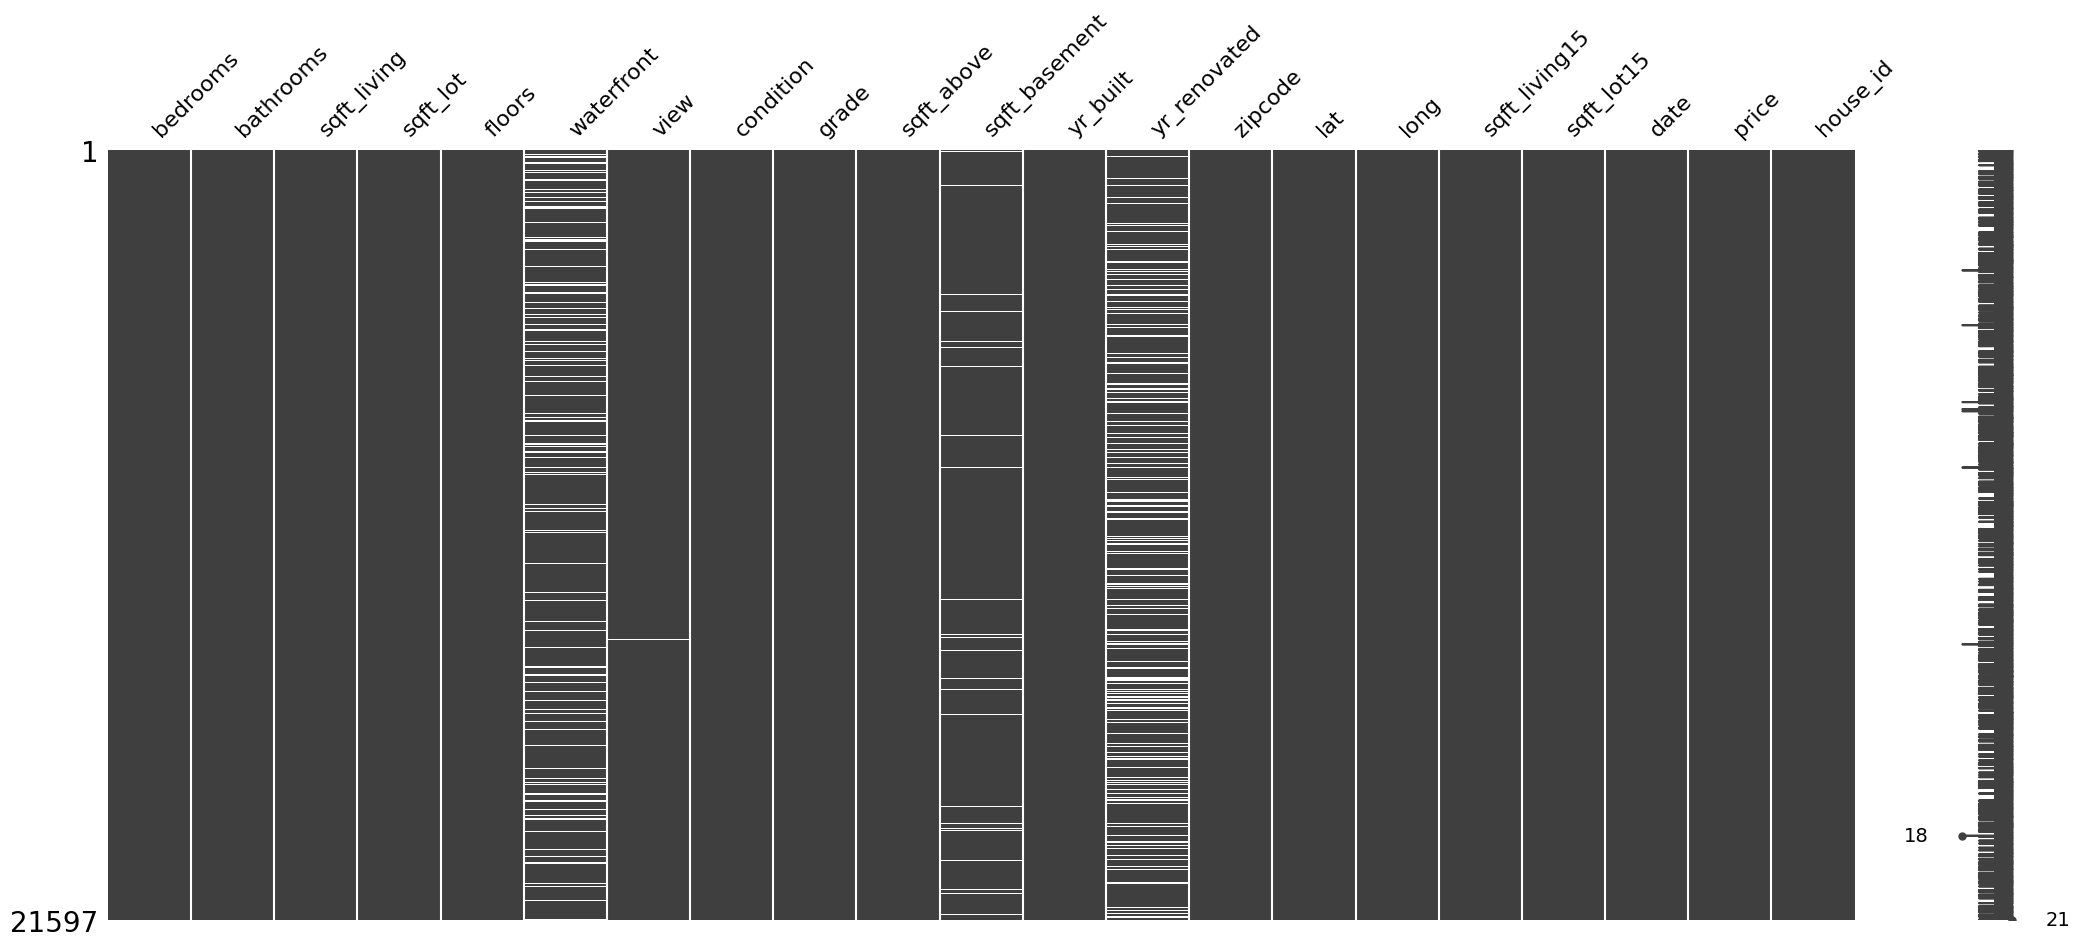

In [7]:
# Check data quality: missing values

print(df.isnull().sum())

import missingno as msgn

df.isna()
print(msgn.matrix(df))

**Outcome**: Some records contain missing values regarding whether the property has a waterfront view (missing values: 2391), the quality of the view (missing values: 63), the basement size in square feet (missing values: 452), and the year of the last renovation (missing values: 3848). Based on logical reasoning, we assume that these missing values indicate that these properties have no waterfront view, no significant view quality, no basement, and that no renovation have taken place.

## Summary statistics for numerical columns

**Outcome**: 

- **Target price**: Properties range in price from 78,000 to 7,700,000 (currency not specified). The large range and high variability indicate substantial dispersion and the presence of extreme values. The distribution is strongly right-skewed, with a few very expensive outliers. Most properties are priced between 322,000 and 645,000, with a median price of approximately 450,000.

- **Sqft-living**: Square footage of living space ranges from a minimum of 370 to a maximum of 13,540. The wide range indicates substantial variation in property sizes, from compact apartments to very large houses. The distribution is strongly right-skewed, meaning that most properties are concentrated in the lower to mid-size range, with a few very large outliers. The median living area is approximately 1,910.00 sqft, representing a typical house size in the dataset.

- **Sqft-lot**: Lot sizes vary significantly, ranging from a minimum of 520 to a maximum of 1,651,359. The distribution is highly right-skewed, indicating that most properties have relatively small to medium-sized lots, while a few properties include exceptionally large land areas. The median lot size is approximately 7,618 sqft, suggesting a predominantly urban to suburban housing structure.

- **Bedrooms**: The number of bedrooms ranges from 1 to 33. The distribution is concentrated in the lower range, with most properties having between 2 and 4 bedrooms. The median number of bedrooms is 3, indicating that typical houses in the dataset are designed for small to medium-sized households. A small number of extreme values suggest unusually large properties or potential data anomalies.

- **Bathrooms**: The number of bathrooms ranges from 0,5 to 8, showing moderate variability across properties. Most houses have between 1 and 2.5 bathrooms, with a median of 2.25. The distribution is slightly right-skewed, indicating that while larger homes exist, the majority of properties remain in the standard residential segment.

The distributions of price, sqft_living, sqft_lot, bedrooms, and bathrooms show strong variability across properties, indicating a highly heterogeneous housing market. All variables exhibit noticeable right-skewness, meaning that most properties are concentrated in the lower to mid-range values, while a small number of extreme observations significantly extend the upper tail.

In particular, price, sqft_lot and sqft_living show pronounced outliers, representing either very large estates or unusual property types. These extreme values increase overall dispersion and can distort averages if not handled carefully. Bedrooms and bathrooms are more concentrated, but still contain a few atypical high-value properties.

Overall, the presence of outliers suggests that the dataset includes both standard residential housing and luxury or exceptional properties. For further analysis, it is important to consider robust statistics (such as median and IQR) and, where appropriate, apply transformations or segmentation (e.g. mid-range filtering) to ensure meaningful comparisons.

### Descriptive Statistics of Price, Area, Bedrooms and Bathrooms

This subsection presents the numerical summary statistics of the selected variables. It highlights key measures such as min, max, mean, median, and quartiles to describe the general structure and variability of the data.

In [8]:
df[["price", "sqft_living", "sqft_lot", "bedrooms", "bathrooms"]].describe().round(2)

,price,sqft_living,sqft_lot,bedrooms,bathrooms
count,21597.00,21597.00,21597.00,21597.00,21597.00
mean,540296.57,2080.32,15099.41,3.37,2.12
std,367368.14,918.11,41412.64,0.93,0.77
min,78000.00,370.00,520.00,1.00,0.50
25%,322000.00,1430.00,5040.00,3.00,1.75
50%,450000.00,1910.00,7618.00,3.00,2.25
75%,645000.00,2550.00,10685.00,4.00,2.50
max,7700000.00,13540.00,1651359.00,33.00,8.00


### Visualizing the Distribution of Price, Area, Bedrooms and Bathrooms

We examine the distribution of important variables to identify skewness, outliers, and overall data spread.

In [9]:
# Setting

def plot_histogram(column, bins=30):
    plt.figure()
    plt.hist(df[column], bins=bins)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()


def plot_bar(df, column):
    plt.figure()
    df[column].value_counts().sort_index().plot(kind="bar")
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()

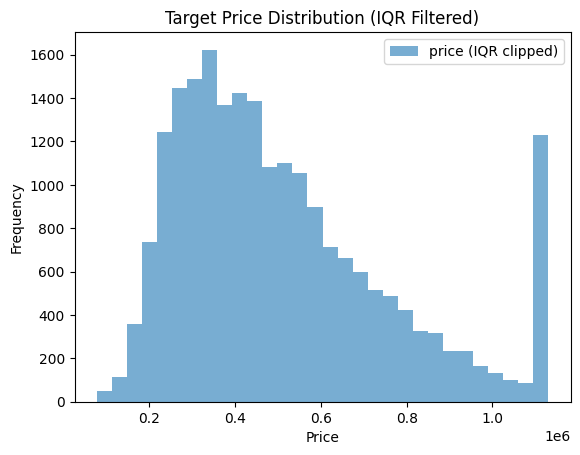

In [10]:
# Distribution of Target Price (outlier filtering via IQR)

import matplotlib.pyplot as plt

## calculate boundaries
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["price_iqr"] = df["price"].clip(lower_bound, upper_bound)

## visualization
plt.figure()

plt.hist(df["price_iqr"], bins=30, alpha=0.6, label="price (IQR clipped)")

plt.title("Target Price Distribution (IQR Filtered)")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.legend()
plt.show()


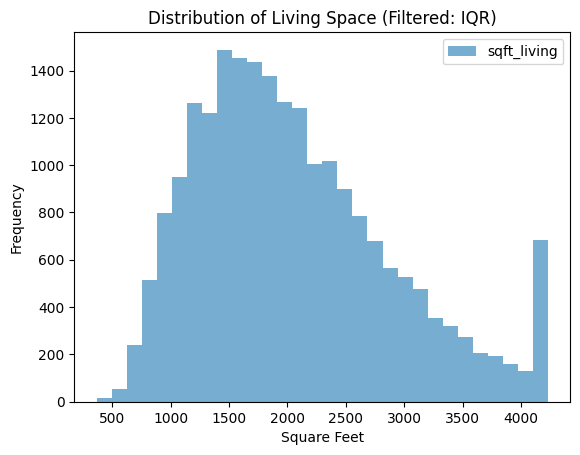

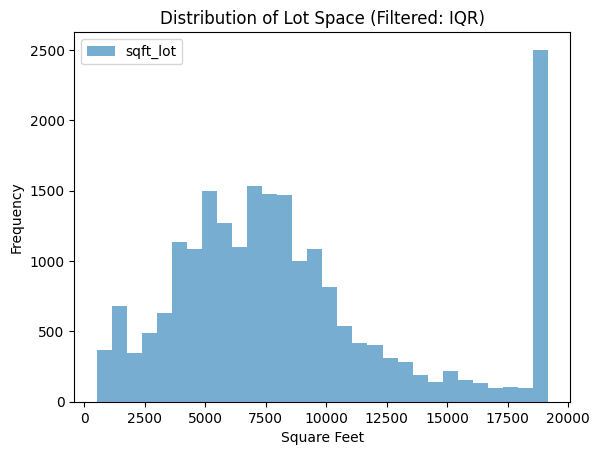

In [11]:
# Distribution of sqft_living and sqft_lot (ex. Outliners)

## calculate boundaries
Q1 = df["sqft_living"].quantile(0.25)
Q3 = df["sqft_living"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["sqft_living_iqr"] = df["sqft_living"].clip(lower_bound, upper_bound)

Q1 = df["sqft_lot"].quantile(0.25)
Q3 = df["sqft_lot"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["sqft_lot_iqr"] = df["sqft_lot"].clip(lower_bound, upper_bound)

## visualization

plt.figure()

plt.hist(df["sqft_living_iqr"], bins=30, alpha=0.6, label="sqft_living")

plt.title("Distribution of Living Space (Filtered: IQR)")
plt.xlabel("Square Feet")
plt.ylabel("Frequency")
plt.legend()
plt.show()


plt.figure()

plt.hist(df["sqft_lot_iqr"], bins=30, alpha=0.6, label="sqft_lot")

plt.title("Distribution of Lot Space (Filtered: IQR)")
plt.xlabel("Square Feet")
plt.ylabel("Frequency")
plt.legend()
plt.show()

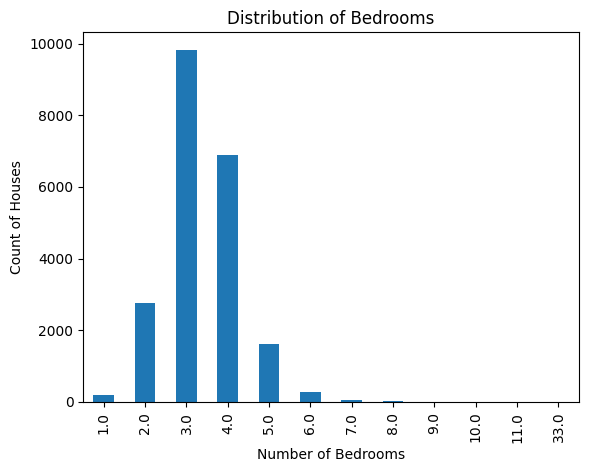

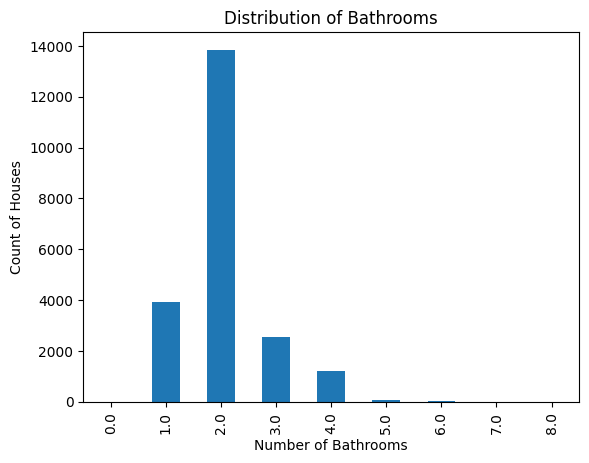

In [12]:
# Distribution of Bedrooms

df["bedrooms"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Count of Houses")
plt.show()

# Distribution of Bathrooms

bath_counts = df["bathrooms"].round().value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Count of Houses")
plt.show()


## Summary statistics for Categorical and Ordinal Variables

We analyze categorical and ordinal features such as grade, condition, view and waterfront.

**Outcome**: 

- **Grade**: The variable grade shows 11 unique levels on a skala from 1 to 13 , with the most given grade of 7 (41,55%). This indicates that most properties are of average construction quality, concentrated around the mid-tier segment. Only a small share of houses falls into very low or luxury-grade categories, suggesting a relatively normal distribution with a slight focus on standard housing quality.

- **Conditions**:Condition has 5 unique levels on a skala from 1 to 5, with the most common condition of 3 (64,92%). This suggests that the majority of properties are in average condition, with relatively few homes in either poor or excellent condition. Overall, the dataset is dominated by standard-maintained properties, with limited variation in extreme conditions.

- **View**: The variable view has 5 categories, but the mode is 0 (90,19%), indicating that most properties do not have a notable view. Only a small fraction of houses benefit from an enhanced view, making this a relatively rare but potentially valuable feature in price determination.

- **Waterfront**: Waterfront is a highly imbalanced binary variable, with the mode being 0 (99,24%). This shows that the vast majority of properties are not located on the waterfront. Waterfront homes are therefore rare and represent a premium segment, likely associated with significantly higher property values.

### Frequencies (absolute and relative) of grade, condition, view and waterfront

This section focuses on the frequency distributions of the categorical and ordinal variables grade, condition, view, and waterfront. While the descriptive statistics provide a numerical summary of central tendencies and dispersion, the frequency analysis offers a more detailed view of how observations are distributed across individual categories.

In [13]:
grade_freq = pd.DataFrame({
    "count": df["grade"].value_counts().sort_index(),
    "%": (df["grade"].value_counts(normalize=True).sort_index() * 100).round(2)
})

grade_freq.T

grade,3,4,5,6,7,8,9,10,11,12,13
count,1.0,27.00,242.00,2038.00,8974.00,6065.00,2615.00,1134.00,399.00,89.00,13.00
%,0.0,0.13,1.12,9.44,41.55,28.08,12.11,5.25,1.85,0.41,0.06


In [14]:
condition_freq = pd.DataFrame({
    "count": df["condition"].value_counts().sort_index(),
    "%": (df["condition"].value_counts(normalize=True).sort_index() * 100).round(2)
})

condition_freq.T

condition,1,2,3,4,5
count,29.00,170.00,14020.00,5677.00,1701.00
%,0.13,0.79,64.92,26.29,7.88


In [15]:
view_freq = pd.DataFrame({
    "count": df["view"].value_counts().sort_index(),
    "%": (df["view"].value_counts(normalize=True).sort_index() * 100).round(2)
})

view_freq.T

view,0.0,1.0,2.0,3.0,4.0
count,19422.00,330.00,957.00,508.00,317.00
%,90.19,1.53,4.44,2.36,1.47


In [16]:
waterfront_freq = pd.DataFrame({
    "count": df["waterfront"].value_counts().sort_index(),
    "%": (df["waterfront"].value_counts(normalize=True).sort_index() * 100).round(2)
})

waterfront_freq.T

waterfront,0.0,1.0
count,19060.00,146.00
%,99.24,0.76


### Distribution of the Categorical and Ordinal Variables

In this section, the distribution of the categorical and ordinal variables grade, condition, view, and waterfront is visualized. While the summary table provides an overview of unique values, modes, and relative frequencies, the visual distribution plots further confirm and complement these findings.

The frequency distributions help validate the central tendencies identified in the table and provide additional insight into how values are distributed across categories. In particular, they highlight whether the data is evenly distributed or dominated by specific categories, and they support the interpretation of potential imbalances or rare features within the dataset.

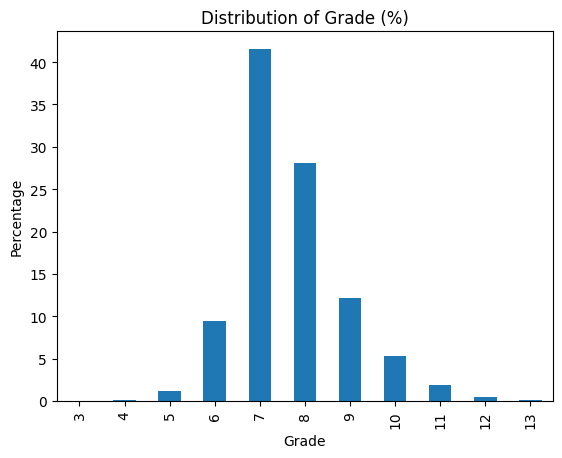

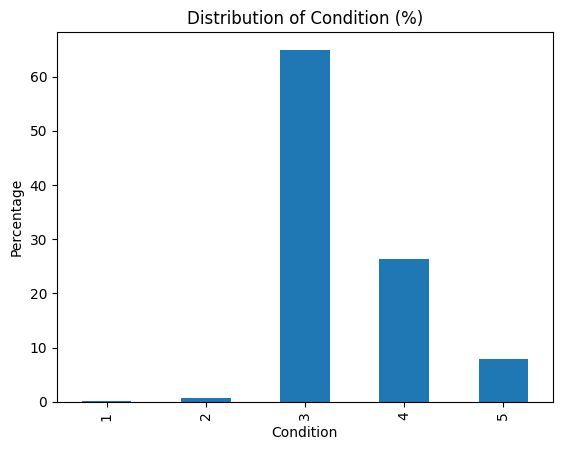

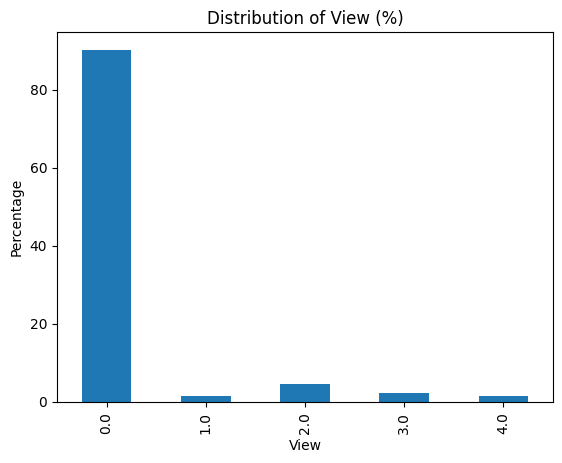

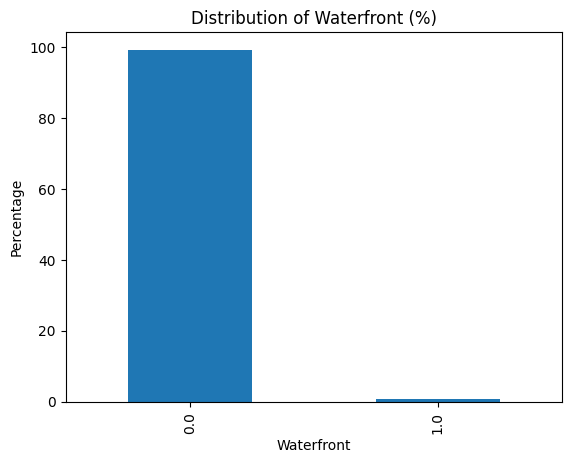

In [17]:
(df["grade"].value_counts(normalize=True) * 100).sort_index().plot(kind="bar")

plt.title("Distribution of Grade (%)")
plt.xlabel("Grade")
plt.ylabel("Percentage")

plt.show()

(df["condition"].value_counts(normalize=True) * 100).sort_index().plot(kind="bar")

plt.title("Distribution of Condition (%)")
plt.xlabel("Condition")
plt.ylabel("Percentage")

plt.show()

(df["view"].value_counts(normalize=True) * 100).sort_index().plot(kind="bar")

plt.title("Distribution of View (%)")
plt.xlabel("View")
plt.ylabel("Percentage")

plt.show()

(df["waterfront"].value_counts(normalize=True) * 100).sort_index().plot(kind="bar")

plt.title("Distribution of Waterfront (%)")
plt.xlabel("Waterfront")
plt.ylabel("Percentage")

plt.show()

## Summary statistics for Temporal Variables

We explore time-related patterns, such as the distribution of sales across months. The objective is to understand the temporal scope of the recorded property transactions and identify potential patterns or concentrations over time.

By analyzing the distribution of sales dates, it becomes possible to assess whether the data captures a consistent time frame, detect seasonal effects, and ensure that the observations are comparable. This temporal context is essential for interpreting price dynamics and supporting reliable conclusions in the subsequent analysis.

**Outcome**: 

- **Date**: The dataset includes property sales from May 2014 to May 2015, specifically from 2014-05-02 to 2015-05-27. The distribution of sales across months shows seasonal patterns, with higher activity in certain periods of the year. May shows the highest sales activity, with 2414 property sales, suggesting increased demand during this period.


### Period data set

This section examines the time period covered by the dataset.

In [18]:
df['date'] = pd.to_datetime(df['date'])

df['date'].min(), df['date'].max()

(Timestamp('2014-05-02 00:00:00'), Timestamp('2015-05-27 00:00:00'))

### Seasonal Trends in Housing Sales

The chart combines transaction volume and average price per month. While the bar chart shows fluctuations in sales activity, the line plot reveals how average prices evolve over time. This allows for the identification of seasonal patterns and potential relationships between demand and pricing.

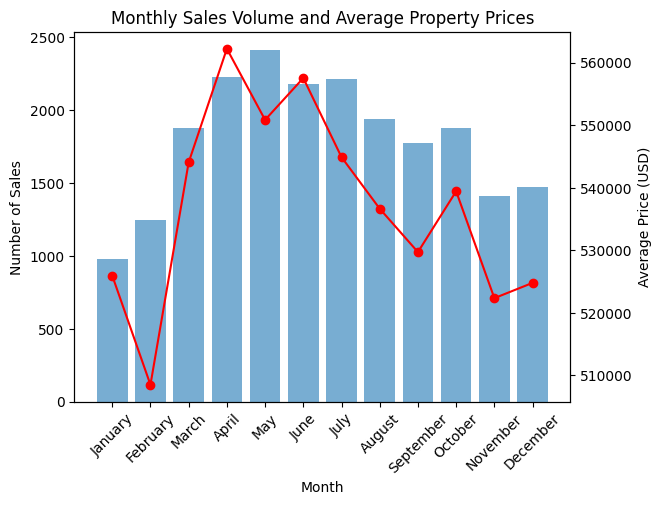

In [19]:
import matplotlib.pyplot as plt

# Create month names
df["month_name"] = df["date"].dt.month_name()

# Define correct order
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

# Sales volume
sales_per_month = df["month_name"].value_counts().reindex(month_order)

# Average price
avg_price_per_month = df.groupby("month_name")["price"].mean().reindex(month_order)

# Plot
fig, ax1 = plt.subplots()

# Bar chart: number of sales
ax1.bar(sales_per_month.index, sales_per_month, alpha=0.6)
ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Sales")
ax1.tick_params(axis='x', rotation=45)

# Line chart: average price
ax2 = ax1.twinx()
ax2.plot(avg_price_per_month.index, avg_price_per_month, marker="o", color="red")
ax2.set_ylabel("Average Price (USD)")

# Title
plt.title("Monthly Sales Volume and Average Property Prices")

plt.show()

In [20]:
# Count Top sales per month
df["month"] = df["date"].dt.month
sales_per_month = df["month"].value_counts().sort_index()
top_month = sales_per_month.idxmax()
top_sales = sales_per_month.max()

top_month, top_sales

(np.int32(5), np.int64(2414))

## Summary statistics for Geospatial Variables

The dataset includes geographic coordinates that allow us to analyze spatial patterns.

**Outcome**: 

- **Zipcode**: The analysis covers 70 different ZIP codes and reveals strong geographic variation within the housing market. Price distributions differ significantly across ZIP codes, indicating that location plays a central role in determining property values.

Overall, there is substantial variation within ZIP codes, largely driven by the presence of luxury properties, which increase both price levels and dispersion. While a few ZIP codes stand out as consistently more expensive, most areas remain within a comparable mid-range segment, with relatively similar baseline price structures.

Higher-priced ZIP codes tend to have fewer available properties, suggesting a more limited and exclusive housing supply. In contrast, other ZIP codes show greater variation in price levels and a more diverse mix of properties across different segments.

The average price per ZIP code is not uniform but shows clear variation, with a general upward differentiation rather than a homogeneous structure. This indicates a segmented market where both location and local property composition contribute to price differences.

- **Lat/Lot**: The spatial distribution reveals a clear clustering of properties, indicating that the housing market is concentrated in specific geographic areas rather than evenly spread. Dense clusters suggest urban or highly populated neighborhoods, while more dispersed points indicate suburban or less developed regions.

These patterns highlight the importance of location as a key factor in the dataset, as property availability and density vary significantly across areas. The identified clusters provide a basis for further location-based analysis, such as comparing price levels and neighborhood characteristics.


### Patterns by zip-codes

This section provides a descriptive overview of the housing market across different ZIP codes. The analysis focuses on comparing transaction volume, price levels, and average property characteristics to identify structural differences between locations.

In [21]:
zip_summary = df.groupby("zipcode").agg({
    "price": ["count", "mean", "median", "min", "max"],
    "sqft_living": "mean",
    "grade": "mean"
}).round(0)

zip_summary

price                                            sqft_living grade
        count       mean     median       min        max        mean  mean
zipcode                                                                   
98001     361   281195.0   260000.0  100000.0   850000.0      1904.0   7.0
98002     199   234284.0   235000.0   95000.0   389000.0      1628.0   7.0
98003     280   294111.0   267475.0  128000.0   950000.0      1929.0   8.0
98004     317  1356524.0  1150000.0  425000.0  7060000.0      2909.0   9.0
98005     168   810290.0   765475.0  400000.0  1960000.0      2657.0   8.0
...       ...        ...        ...       ...        ...         ...   ...
98177     255   676419.0   554000.0  245560.0  3800000.0      2323.0   8.0
98178     262   310613.0   278277.0   90000.0  1700000.0      1729.0   7.0
98188     136   289078.0   264000.0  110000.0   707000.0      1803.0   7.0
98198     280   302897.0   265000.0   95000.0  1350000.0      1745.0   7.0
98199     317   792188.0   689800.0  323000.0  3200000.0      2162.0   8.0

[70 rows x 7 columns]

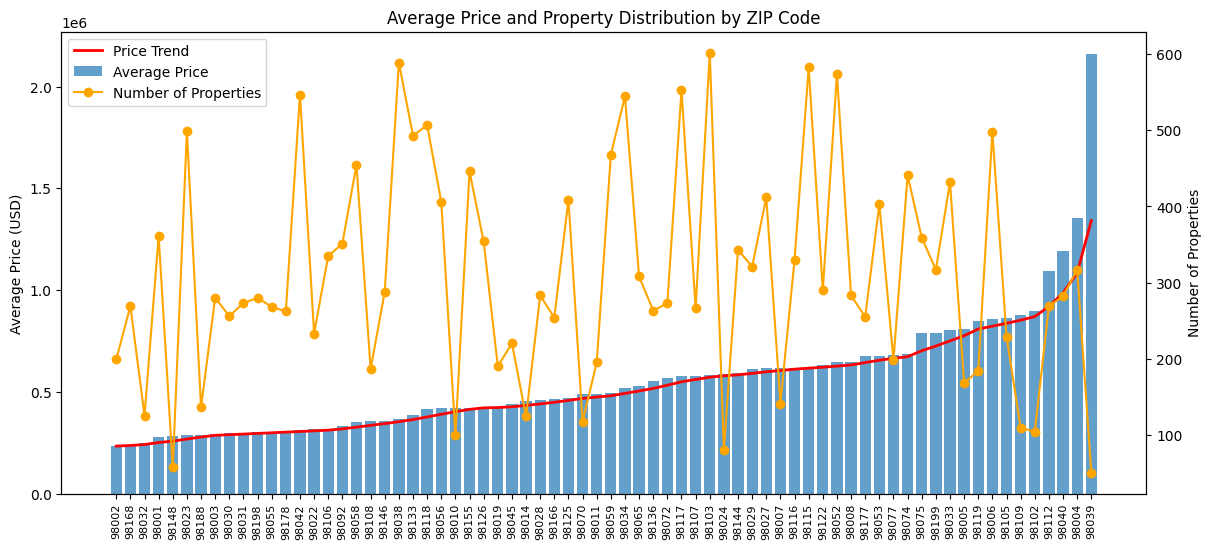

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Mean price per ZIP code (sorted)
means = df.groupby("zipcode")["price"].mean().sort_values()

# Number of properties per ZIP code (aligned with same index)
counts = df["zipcode"].value_counts().reindex(means.index)

x = np.arange(len(means))

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart: Average Price
ax1.bar(x, means.values, alpha=0.7, label="Average Price")
ax1.set_ylabel("Average Price (USD)")

# Trend line
trend = pd.Series(means.values).rolling(window=5, min_periods=1).mean()
ax1.plot(x, trend, color="red", linewidth=2, label="Price Trend")

# Second axis: Number of Properties
ax2 = ax1.twinx()
ax2.plot(x, counts.values, color="orange", marker="o", label="Number of Properties")
ax2.set_ylabel("Number of Properties")

# X-axis formatting
ax1.set_xticks(x)
ax1.set_xticklabels(means.index, rotation=90, fontsize=8)

# Title
plt.title("Average Price and Property Distribution by ZIP Code")

# Combined legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.show()

<Figure size 48000x4000 with 0 Axes>

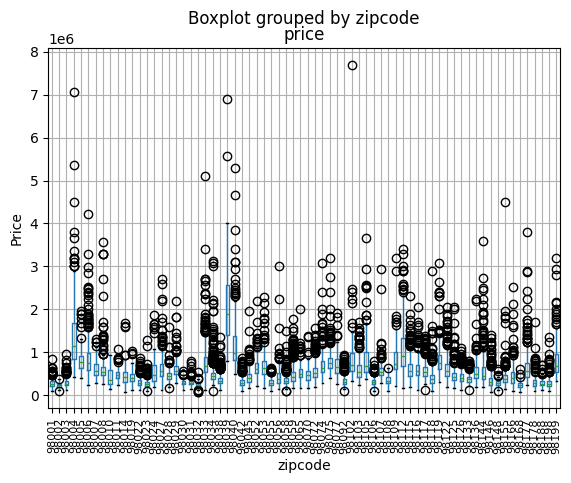

In [23]:
plt.figure(figsize=(480, 40))
df.boxplot(column="price", by="zipcode", rot=90)

plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Price")
plt.show()

### Distribution of properties based on coordinates (address)

This section explores the spatial distribution of properties based on their geographic coordinates (latitude and longitude). By visualizing the locations of the properties, patterns such as clustering, urban density, and potential neighborhood structures become visible.

The objective is to gain a better understanding of how properties are distributed across the region and to identify areas with higher concentrations of listings. This spatial perspective provides important context for interpreting location-based factors that may influence property prices and buyer preferences.

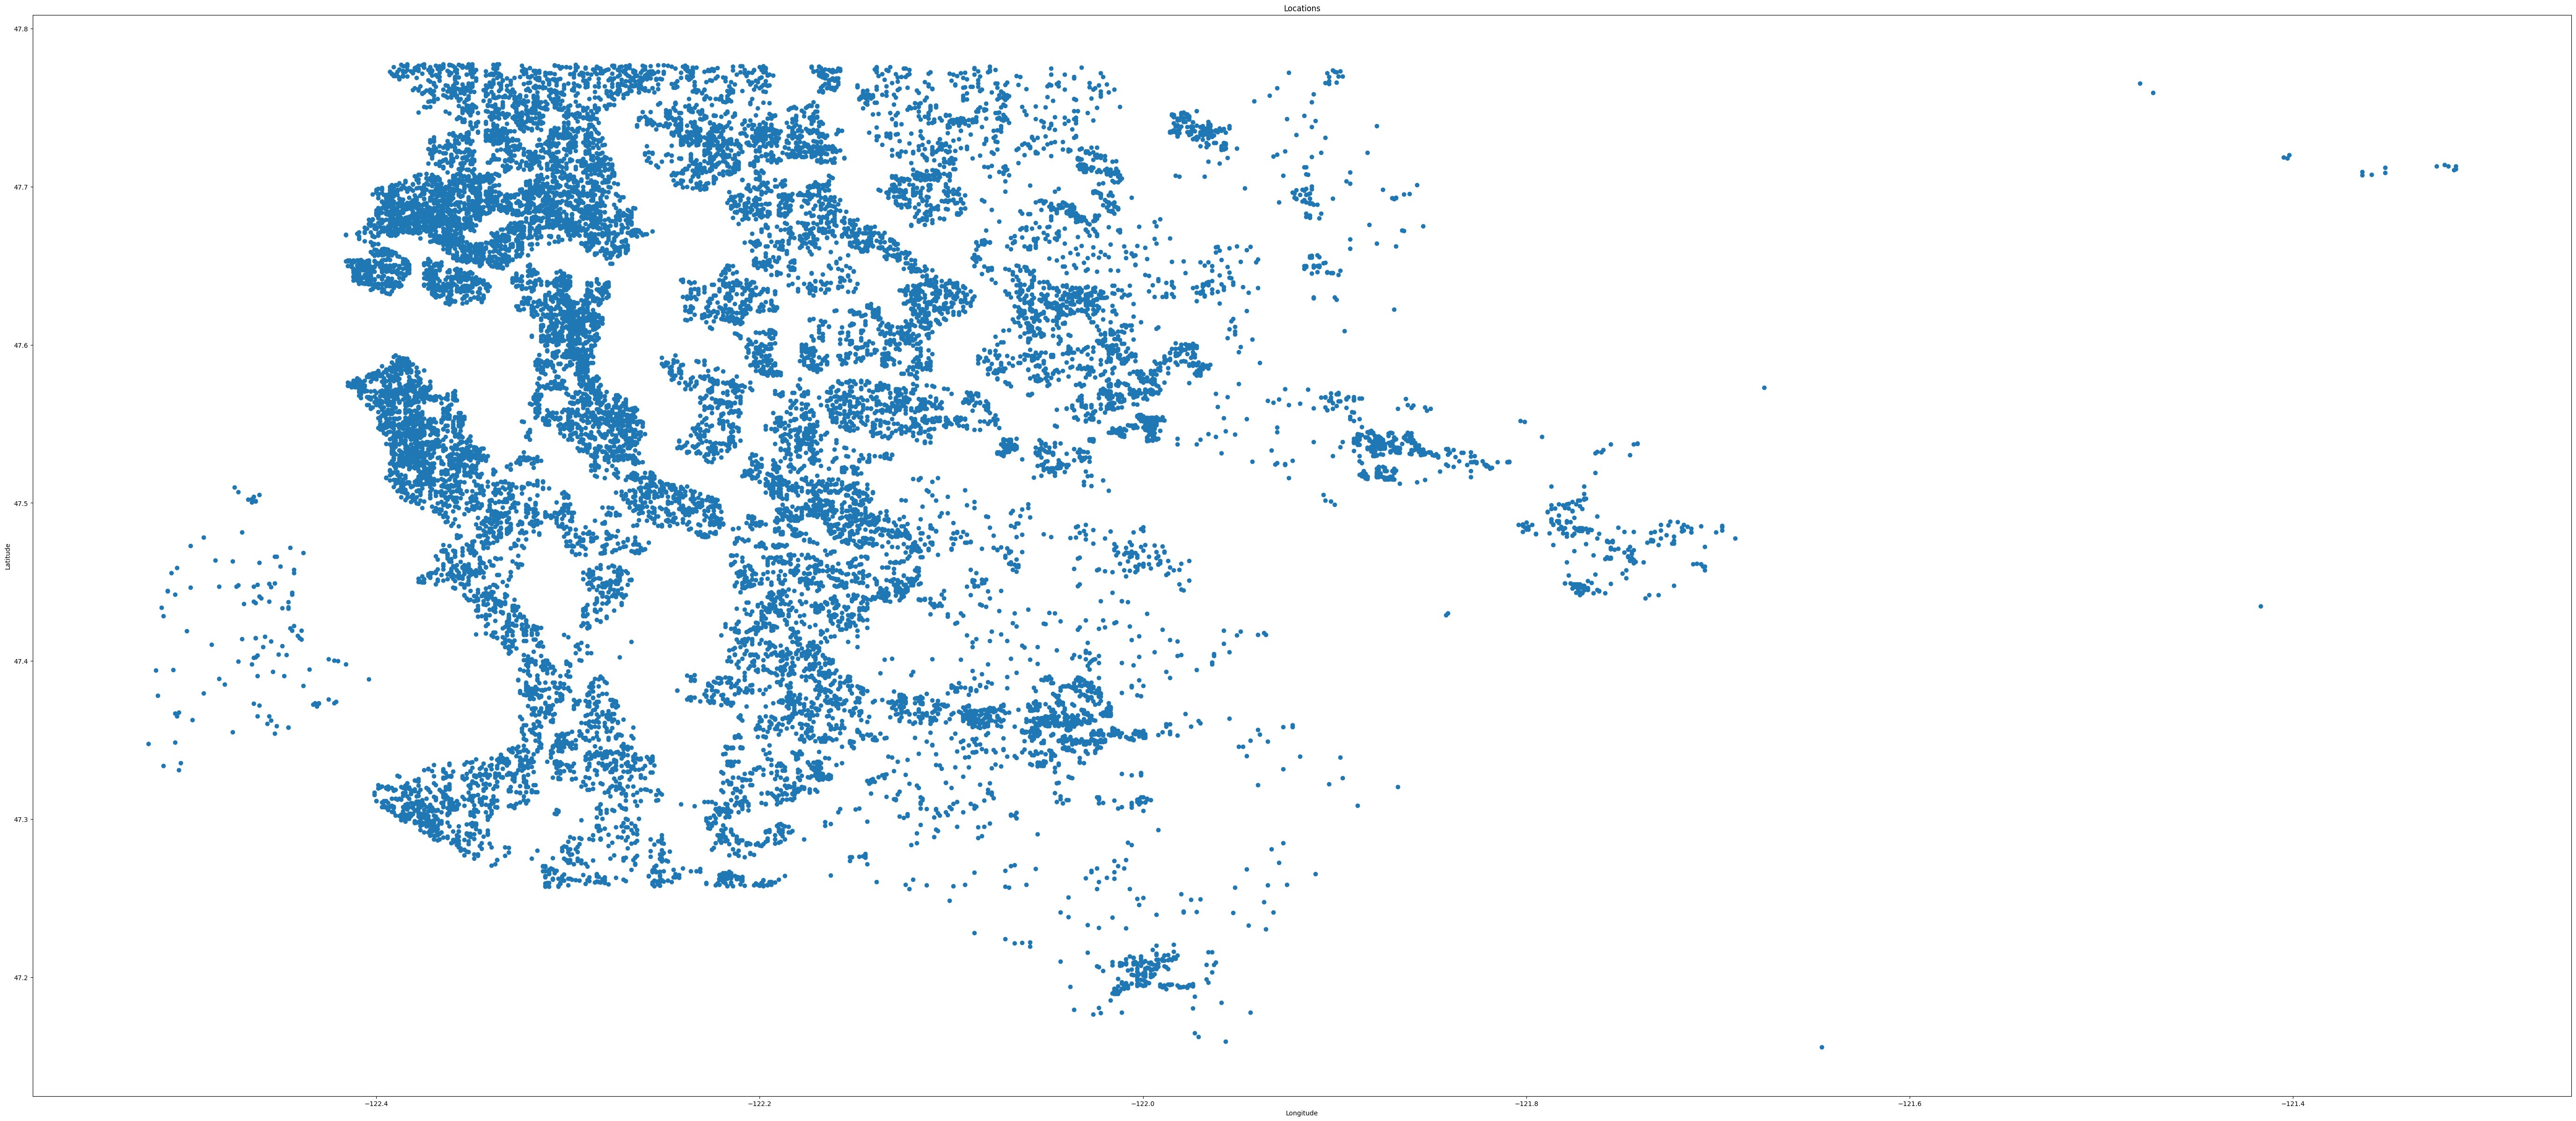

In [24]:
#Check Coordinates
import matplotlib.pyplot as plt

plt.figure(figsize=(70,30))
plt.scatter(df["long"], df["lat"])

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Locations")
plt.show()


## Additional Variables

In addition to the original dataset, several derived variables are introduced to support a more detailed exploratory analysis. These features help to better understand property structure, age, and spatial characteristics.

The analysis considers basic structural attributes such as floors, sqft_above, and sqft_basement, which describe the physical composition of each property.

Furthermore, additional engineered variables are created, including house age, renovation status, and the living-to-lot ratio. These features provide deeper insights into property characteristics and support a more structured interpretation of the housing dataset.

More advanced benchmark variables, such as living and lot benchmarks, are introduced later in the analysis to enable comparative neighborhood-level evaluation.

**Outcome**:

- **Floors**: The number of floors ranges from 1 to 3.5. The distribution is concentrated in the lower range, with most properties having between 1 and 2 floors. The median number of floors is 1.5, indicating that typical houses in the dataset are predominantly single-family or low-rise residential properties.

- **sqft_above**: The above-ground living area varies significantly, ranging from 370 to 9,410 sqft. The distribution is strongly right-skewed, indicating that most properties are relatively small to medium-sized, while a small number of very large homes create a long upper tail. The median living area above ground is approximately 1,560 sqft, suggesting a predominantly suburban housing structure with some high-end outliers.
  
- **sqft_basement**: Basement area ranges from 10 to 4,820 sqft, but a large share of properties (38.5%) do not have a basement at all. This creates a highly skewed distribution with a strong concentration at zero. Among properties with basements, the median basement size is approximately 700 sqft, indicating that when present, basements tend to represent a substantial additional living space.

- **House age**: The age of the houses varies considerably, ranging from newly built properties to very old buildings with a maximum age of 115 years. The median house age is approximately 40 years, indicating that most properties are relatively established but not extremely old. Interestingly, the most common value is around 9 years, suggesting a notable share of newer constructions within the dataset.

Overall, there is a general tendency for the number of listings to decrease as house age increases, indicating that older properties are less frequently offered on the market. However, this trend is not strictly linear, as a secondary concentration of very old houses (80+ years) is also observable, likely reflecting historical properties or long-standing housing stock that remains in circulation.

- **Renovation indicator**: The renovation indicator shows a strong imbalance, with the majority of properties not having been renovated. Out of 21,597 houses, only 744 have recorded renovation activity, indicating that renovations are relatively rare in the dataset.

For renovated properties, the time since renovation varies significantly, ranging from very recent updates to renovations completed up to 80 years ago. The average time since renovation is approximately 15 years, with noticeable peaks around 10, 20, and 30 years ago, suggesting periodic renovation cycles.

Overall, renovation activity represents a distinct but limited characteristic within the housing market, potentially contributing to value differentiation between otherwise similar properties.

- **Living-to-lot ratio**: The living-to-lot ratio shows a highly right-skewed distribution, indicating that most properties have relatively large land sizes compared to their living area. The median value of approximately 0.25 suggests generally low building density, which is typical for suburban housing structures. However, the mean is pulled upward by a small number of extreme values, reflecting either very dense urban properties or data-driven outliers.

Overall, the ratio exhibits strong variability across properties, highlighting substantial differences in how land is utilized relative to building size. While most houses are characterized by low density (small living area relative to lot size), a smaller subset shows significantly higher density levels.

In total, 788 extreme outliers were identified, primarily driven by unusually high ratios caused by very small lot sizes relative to living areas. Additionally, values above 1 indicate cases where the living area exceeds the lot size, which may reflect data inconsistencies, highly atypical property structures, or measurement issues. These observations should be treated carefully in subsequent analysis to avoid bias in interpretation.

### Descriptive and visualized analysis of more features

This section extends the descriptive analysis by focusing on additional structural property features, including basement area, above-ground living space, and number of floors. These variables provide a more detailed understanding of the physical composition of the houses in the dataset.

Both statistical summaries and visualizations are used to explore their distributions, identify patterns, and detect potential outliers. This helps to better understand how building structure varies across properties and complements the previous analysis of size-related features.

In [25]:
df[["floors", "sqft_above"]].describe().round(2)

,floors,sqft_above
count,21597.00,21597.00
mean,1.49,1788.60
std,0.54,827.76
min,1.00,370.00
25%,1.00,1190.00
50%,1.50,1560.00
75%,2.00,2210.00
max,3.50,9410.00


In [26]:
# Set assumption: missing value = no basement = 0
df["sqft_basement"] = df["sqft_basement"].fillna(0) 

# filter no basement 
df[df["sqft_basement"] > 0]["sqft_basement"].describe().round(2)


count    8318.00
mean      741.92
std       404.74
min        10.00
25%       450.00
50%       700.00
75%       980.00
max      4820.00
Name: sqft_basement, dtype: float64

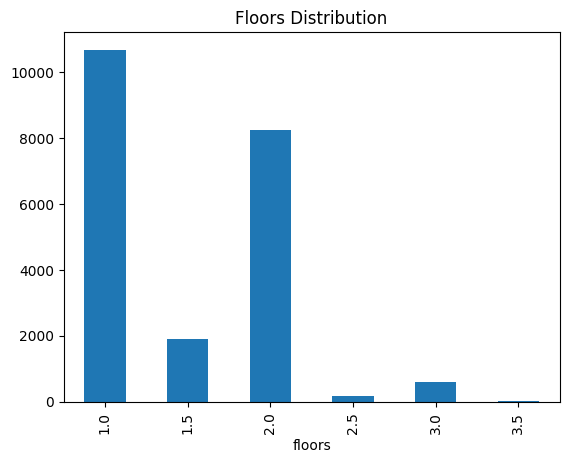

In [27]:
df["floors"].value_counts().sort_index().plot(kind="bar")
plt.title("Floors Distribution")
plt.show()

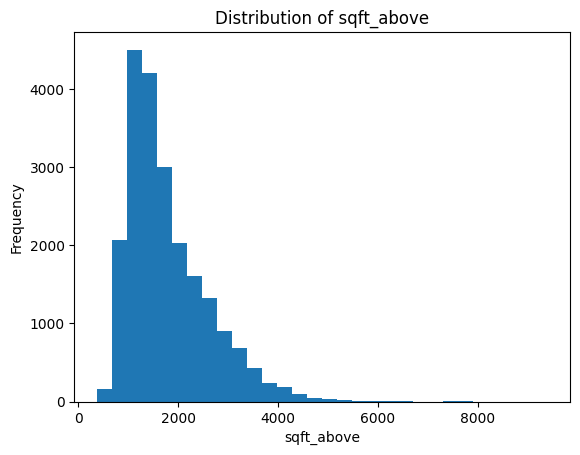

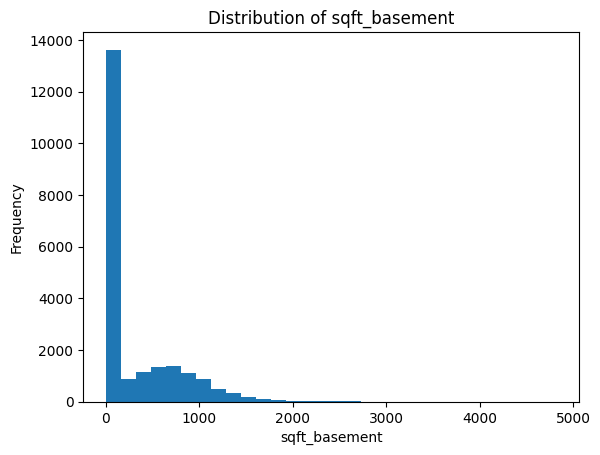

In [28]:
#Verteilung
plot_histogram("sqft_above")
plot_histogram("sqft_basement")

### House Age-Indicator

This section focuses on house age as a key structural indicator within the housing dataset. It captures the temporal dimension of each property by reflecting the time elapsed since construction at the point of sale.

The analysis provides both a descriptive overview and a distributional perspective in order to understand how old or new the properties in the market are. This helps to contextualize housing characteristics in relation to building lifecycle and market composition.

In [29]:
# Action: yr_built adjusted
df["yr_built"] = pd.to_numeric(df["yr_built"], errors="coerce").astype("Int64")

#New_Variable: Age of House
df["year_sold"] = df["date"].dt.year
df["house_age"] = df["year_sold"] - df["yr_built"]

df["house_age"].describe()

count      21597.0
mean     43.323286
std      29.377285
min           -1.0
25%           18.0
50%           40.0
75%           63.0
max          115.0
Name: house_age, dtype: Float64

In [30]:
df["house_age"].mode()

0    9
Name: house_age, dtype: Int64

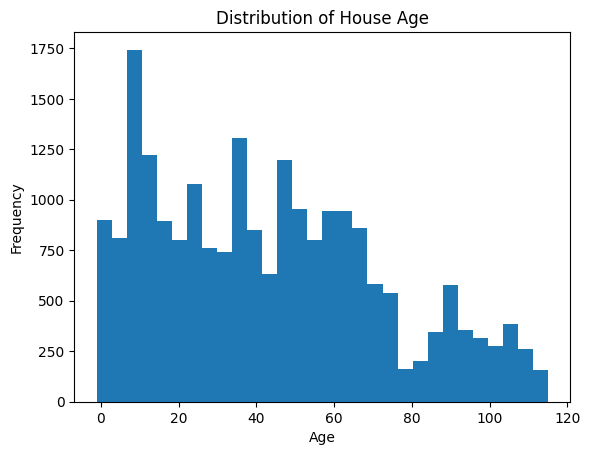

In [31]:
plt.figure()
plt.hist(df["house_age"], bins=30)
plt.title("Distribution of House Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Renovation-Score-Indicator

This section introduces the renovation score as an indicator of property modernization. It captures whether and to what extent a house has undergone renovation, providing an additional dimension for assessing property quality and potential value differences within the housing market.

In [32]:
#Scale correction

df["yr_renovated"] = df["yr_renovated"].apply(
    lambda x: x / 10 if x > 10000 else x)

#New_Variable: Last Renovation
df["year_sold"] = df["date"].dt.year
df["renovation_last"] = df["year_sold"] - df["yr_renovated"]

df["yr_renovated"] = df["yr_renovated"].replace(0, None)

df["renovation_last"].describe().round(0)

count    17749.0
mean      1931.0
std        400.0
min         -1.0
25%       2014.0
50%       2014.0
75%       2015.0
max       2015.0
Name: renovation_last, dtype: float64

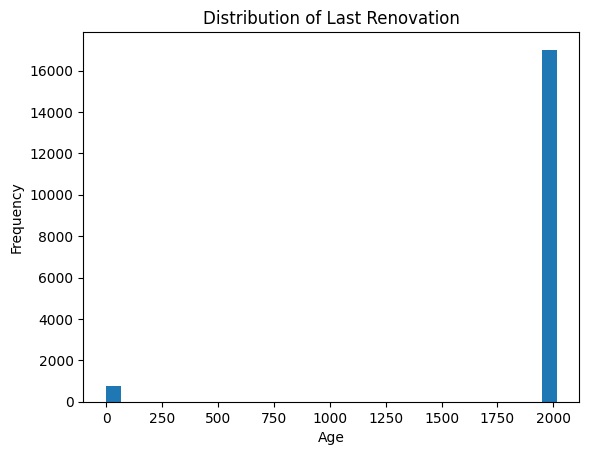

In [33]:
plt.figure()
plt.hist(df["renovation_last"], bins=30)
plt.title("Distribution of Last Renovation")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [34]:
df["renovation_score"] = 0
df.loc[df["yr_renovated"] > 0, "renovation_score"] = 1

### Living-Lot-Ratio-Indicator

This section introduces the living-to-lot ratio as a structural indicator of property composition. It measures the relationship between the living area and the total lot size, providing insight into how efficiently land is utilized across properties.

The indicator helps to better understand differences in housing density and spatial usage patterns within the dataset. It serves as an additional feature for describing property structure beyond absolute size measures.

In [35]:
#Testing data quality

(df["sqft_lot"] == 0).sum()

np.int64(0)

In [36]:
#living space relative to lot size
df["living_to_lot_ratio"] = df["sqft_living"] / df["sqft_lot"].replace(0, np.nan)

df["living_to_lot_ratio"].describe().round(3)

count    21597.000
mean         0.324
std          0.268
min          0.001
25%          0.157
50%          0.248
75%          0.408
max          4.654
Name: living_to_lot_ratio, dtype: float64

In [37]:
# Sum of Outliners
(df["living_to_lot_ratio"] > 1).sum()

np.int64(788)

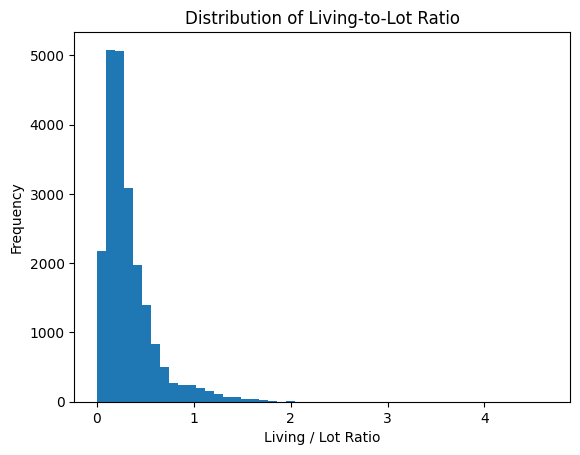

In [38]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["living_to_lot_ratio"], bins=50)
plt.title("Distribution of Living-to-Lot Ratio")
plt.xlabel("Living / Lot Ratio")
plt.ylabel("Frequency")
plt.show()
